# Loading with Himawari Satellite Data

This notebook will demonstrate how toaccess Himawari Satellite data stored in a site archive.

In [6]:
import warnings
import datetime

In [30]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
import pyearthtools.data
import pyearthtools.pipeline
import pyearthtools.pipeline.operations.xarray.normalisation

If you are at a different site, please replace the NCI Site Archive import with the site archive for your platform.

In [3]:
import site_archive_nci

### Acessing the data through the PyEarthTools
Here we will access satellite observations data from bands 1 and 2 through the PyEarthTools site archive.

In [23]:
himawari_bands = ['OBS_B01', 'OBS_B02']
# selected_date = datetime.datetime(2020,10,3,6,0)
selected_date = '20201003T0600' 

In [5]:
sat_accessor = pyearthtools.data.archive.HimawariChannels(bands=himawari_bands)

In [24]:
ds = sat_accessor[selected_date]
ds

/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/data/indexes/utilities/fileload.py:83: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.open_mfdataset(
/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/data/indexes/utilities/fileload.py:83: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.open_m

<xarray.Dataset> Size: 968MB
Dimensions:                       (time: 1, y: 11000, x: 11000)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2020-10-03T06:00:00
  * x                             (x) float64 88kB -5.5e+06 ... 5.5e+06
  * y                             (y) float64 88kB 5.5e+06 ... -5.5e+06
Data variables:
    channel_0002_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
    geostationary                 (time) float32 4B 9.969e+36
    scan_line_time                (time, y) datetime64[ns] 88kB dask.array<chunksize=(1, 11000), meta=np.ndarray>
    channel_0001_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
Attributes: (12/56)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    acknowledgment:                  See disclaimer
    cdm_data_type:                   grid
    comment:                         AGLS observations geometry product
    contributor_name:                Commonwealth of Australia, Bureau of Met...
    ...                              ...
    time_coverage_end:               20201003T060941Z
    time_coverage_start:             20201003T060022Z
    wmo_platform_name:               Himawari-8
    wmo_satellite_number:            173
    NCO:                             netCDF Operators version 4.7.7 (Homepage...
    product_version:                 1.0

In [25]:
satpipe = pyearthtools.pipeline.Pipeline(
    sat_accessor
)

In [27]:
satpipe

In [26]:
X = satpipe[selected_date]

/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/data/indexes/utilities/fileload.py:83: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.open_mfdataset(
/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/data/indexes/utilities/fileload.py:83: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.open_m

In [28]:
X

<xarray.Dataset> Size: 968MB
Dimensions:                       (time: 1, y: 11000, x: 11000)
Coordinates:
  * time                          (time) datetime64[ns] 8B 2020-10-03T06:00:00
  * x                             (x) float64 88kB -5.5e+06 ... 5.5e+06
  * y                             (y) float64 88kB 5.5e+06 ... -5.5e+06
Data variables:
    channel_0002_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
    geostationary                 (time) float32 4B 9.969e+36
    scan_line_time                (time, y) datetime64[ns] 88kB dask.array<chunksize=(1, 11000), meta=np.ndarray>
    channel_0001_scaled_radiance  (time, y, x) float32 484MB dask.array<chunksize=(1, 3040, 11000), meta=np.ndarray>
Attributes: (12/56)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    acknowledgment:                  See disclaimer
    cdm_data_type:                   grid
    comment:                         AGLS observations geometry product
    contributor_name:                Commonwealth of Australia, Bureau of Met...
    ...                              ...
    time_coverage_end:               20201003T060941Z
    time_coverage_start:             20201003T060022Z
    wmo_platform_name:               Himawari-8
    wmo_satellite_number:            173
    NCO:                             netCDF Operators version 4.7.7 (Homepage...
    product_version:                 1.0

### Visualise the data
We can now use standard plotting methods, such as the xarray plotting interface, to visualise the data.

CPU times: user 12.4 s, sys: 1.68 s, total: 14.1 s
Wall time: 13.9 s


Text(0.5, 1.0, 'Himawari Band 1 - 20201003T0600')

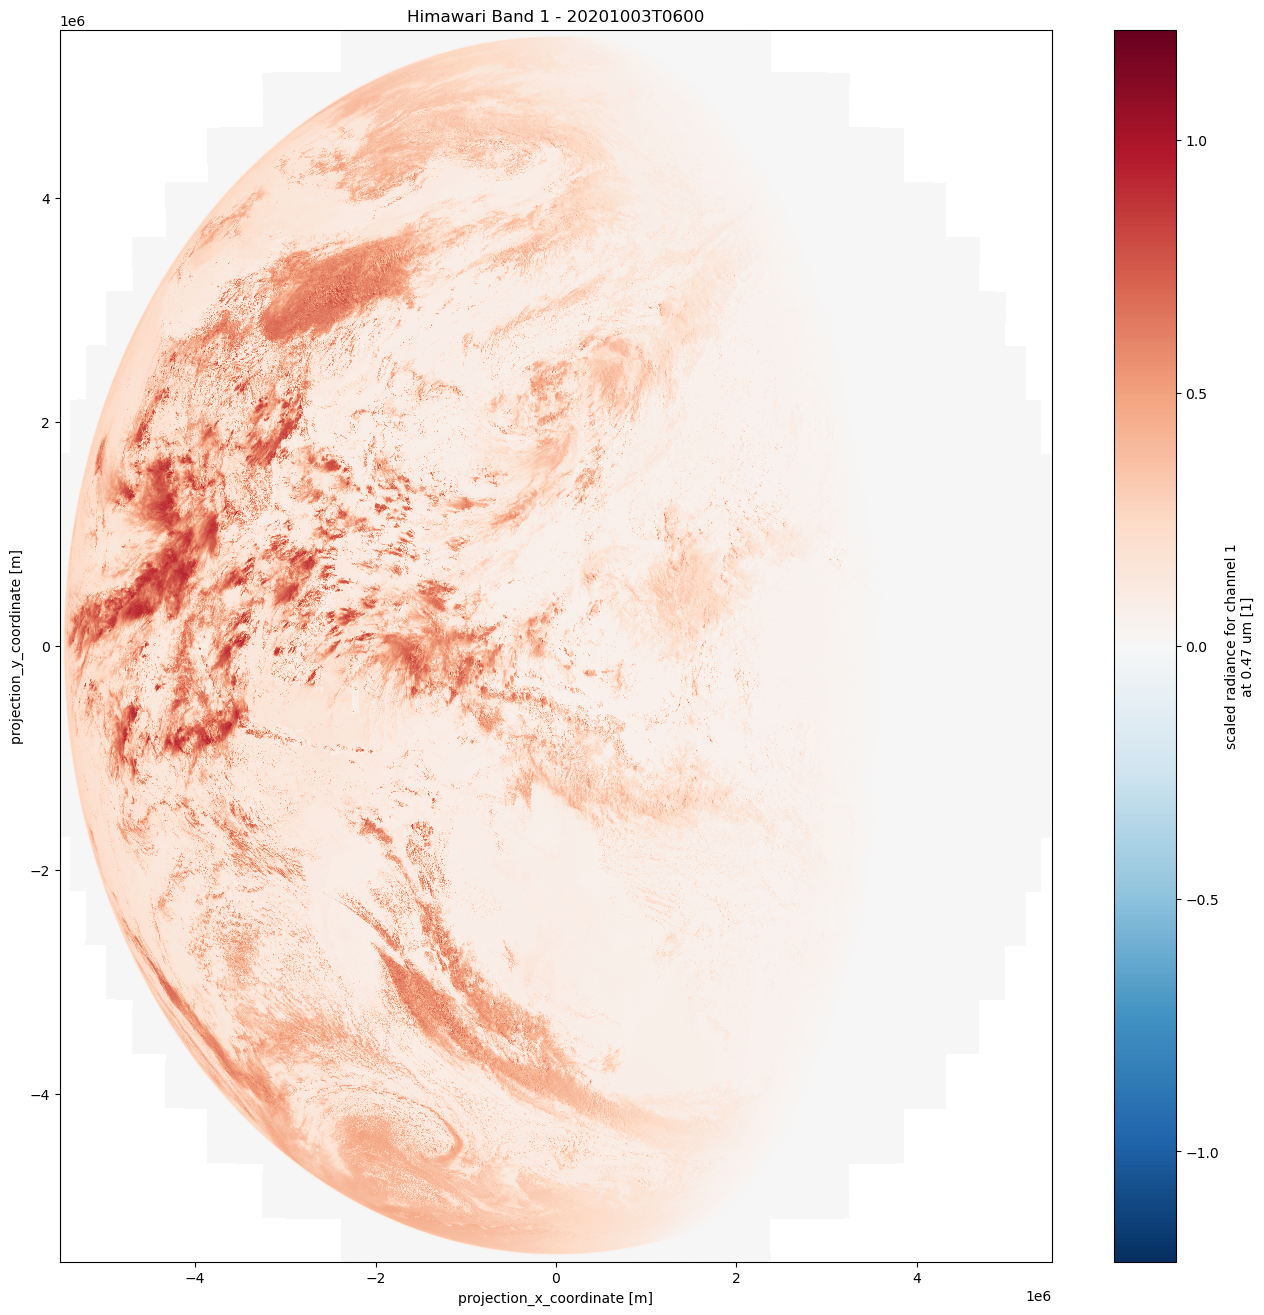

In [31]:
%%time 
#Takes a long time due to the projection involved
X.channel_0001_scaled_radiance.plot(figsize=(16,16))
plt.title(f'Himawari Band 1 - {selected_date}')

## Useful Links

Information on the Himawari satellites
* [Himawari-8 wikipedia](https://en.wikipedia.org/wiki/Himawari_8)
* [Himawari Info - Bureau of Meteorology](https://www.bom.gov.au/climate/how/newproducts/himawari-irradiance.shtml)
* [Himawari Visualisation - NICT Japan](https://himawari8.nict.go.jp/)
* [Himawari Data in AWS Open Data Registry](https://registry.opendata.aws/noaa-himawari/) 

PyEarthTools Docs
* [ArchiveIndex class](https://pyearthtools.readthedocs.io/en/latest/api/data/data_api.html#pyearthtools.data.indexes.ArchiveIndex)